# **Extended State Estimation**  

## Kalman filter

### 1. Mise en place du modèle et des paramètres

Importations

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Paramètres physiques du modèle

In [3]:
# Constantes
f0 = 50.0                         # Hz
omega0 = 2 * np.pi * f0           # rad/s

# Paramètres des générateurs
J1, J2 = 0.4, 0.1
D1, D2 = 0.04, 0.02

alpha1, alpha2 = 100.0, 100.0
beta1, beta2 = 2000.0, 2000.0

Pr1, Pr2 = 100.0, 50.0

# Consignes de puissance
P01, P02 = 600.0, 400.0

# Contrôle secondaire
Ks = 0.05

# Paramètre de ligne
KL = 3064.0  # MW / rad (2 lignes)


Données de puissances des charges

In [4]:
PL1 = 400.0  # MW
PL2 = 600.0  # MW

In [5]:
print("Paramètres du système de deux générateurs:")
print(f"Fréquence nominale: {f0} Hz")
print(f"Inerties: J1={J1}, J2={J2}")
print(f"Amortissements: D1={D1}, D2={D2}")
print(f"Constantes de gouverneur: alpha1={alpha1}, beta1={beta1}, alpha2={alpha2}, beta2={beta2}")
print(f"Puissances mécaniques nominales: Pr1={Pr1} MW, Pr2={Pr2} MW")
print(f"Consignes de puissance: P01={P01} MW, P02={P02} MW")
print(f"Constante de contrôle secondaire: Ks={Ks}")
print(f"Constante de ligne: KL={KL} MW/rad")
print(f"Charges connectées: PL1={PL1} MW, PL2={PL2} MW")

Paramètres du système de deux générateurs:
Fréquence nominale: 50.0 Hz
Inerties: J1=0.4, J2=0.1
Amortissements: D1=0.04, D2=0.02
Constantes de gouverneur: alpha1=100.0, beta1=2000.0, alpha2=100.0, beta2=2000.0
Puissances mécaniques nominales: Pr1=100.0 MW, Pr2=50.0 MW
Consignes de puissance: P01=600.0 MW, P02=400.0 MW
Constante de contrôle secondaire: Ks=0.05
Constante de ligne: KL=3064.0 MW/rad
Charges connectées: PL1=400.0 MW, PL2=600.0 MW


Définition du vecteur d'état
$$X = [\theta_1, \omega_1, T_{m1}, \theta_2, \omega_2, T_{m2}, N]$$

In [6]:
def unpack_state(X):
    theta1, omega1, Tm1, theta2, omega2, Tm2, N = X
    return theta1, omega1, Tm1, theta2, omega2, Tm2, N

def pack_state(theta1, omega1, Tm1, theta2, omega2, Tm2, N):
    return np.array([theta1, omega1, Tm1, theta2, omega2, Tm2, N])

print("Vecteur d'état initial:", pack_state(0, 0, Pr1, 0, 0, Pr2, 0))

Vecteur d'état initial: [  0.   0. 100.   0.   0.  50.   0.]


Fonction dynamique continue (modèle réel)

$$
\text{dynamics}(X_0) = \frac{dX}{dt} = 
\begin{bmatrix} 
\dot{\theta}_1 \\ \dot{\omega}_1 \\ \dot{T}_{m1} \\ \dot{\theta}_2 \\ \dot{\omega}_2 \\ \dot{T}_{m2} \\ \dot{N} 
\end{bmatrix} 
=
\begin{cases}
\frac{d\theta_1}{dt} = \omega_1 - \omega_0 \\
\frac{d\omega_1}{dt} = \frac{1}{J_1} \left[ T_{m1} - \frac{P_{G1}}{\omega_0} - D_1(\omega_1 - \omega_0) \right] \\
\frac{{dT}_{m1}}{dt} \\
\dots \\
\frac{dN}{dt} = -K_s(\omega_r - \omega_0) \\
\end{cases}
$$

In [7]:
def dynamics(X): #dX/dt
    theta1, omega1, Tm1, theta2, omega2, Tm2, N = unpack_state(X)

    # Flux et puissances
    F12 = KL * (theta1 - theta2)
    PG1 = PL1 + F12
    PG2 = PL2 - F12

    # Fréquence moyenne
    omega_r = (J1 * omega1 + J2 * omega2) / (J1 + J2)

    # Dynamique
    dtheta1 = omega1 - omega0
    domega1 = (Tm1 - PG1 / omega0 - D1 * (omega1 - omega0)) / J1
    dTm1 = -alpha1 * (Tm1 * omega0 - (P01 + N * Pr1)) - beta1 * (omega1 - omega0)

    dtheta2 = omega2 - omega0
    domega2 = (Tm2 - PG2 / omega0 - D2 * (omega2 - omega0)) / J2
    dTm2 = -alpha2 * (Tm2 * omega0 - (P02 + N * Pr2)) - beta2 * (omega2 - omega0)

    dN = -Ks * (omega_r - omega0)

    return np.array([dtheta1, domega1, dTm1,
                     dtheta2, domega2, dTm2,
                     dN])


Conditions initiales

In [8]:
X0 = np.array([
    0.0,           # theta1
    omega0 * 1.01, # omega1 (écart initial)
    0.8,           # Tm1
    0.0,           # theta2
    omega0 * 0.99, # omega2
    0.6,           # Tm2
    0.0            # N
])

print("État initial du système:", X0)

État initial du système: [  0.         317.30085801   0.8          0.         311.01767271
   0.6          0.        ]


Paramètres temporels

In [146]:
T_sim = 60.0     # durée de simulation (s)
dt_true = 0.01  # pas fin (courbe vraie)
dt_euler = 0.00005  # pas Euler (à discuter) --> initialement 0.05, trop grand

print(f"Durée de simulation: {T_sim} s")
print(f"Pas de temps pour la courbe vraie: {dt_true} s")  
print(f"Pas de temps pour l'intégration d'Euler: {dt_euler} s")

Durée de simulation: 60.0 s
Pas de temps pour la courbe vraie: 0.01 s
Pas de temps pour l'intégration d'Euler: 5e-05 s


In [147]:
print("dX/dt à t=0 :")
print(dynamics(X0))

dX/dt à t=0 :
[ 3.30085801e+00 -3.77474336e-01  2.82782840e+04 -2.98232729e+00
  1.67149927e-01  2.71246546e+04 -7.96326795e-03]


### 2. Courbes vraie, d'Euler et bruitée

Courbe vraie : intégration du modèle continue

In [148]:
# Import du solveur
from scipy.integrate import solve_ivp

In [149]:
# Fonction d'intégration continue
def dynamics_continuous(t, X):
    return dynamics(X)

In [150]:
# Intégration
t_span = (0.0, T_sim)
t_eval = np.arange(0.0, T_sim, dt_true)

sol_true = solve_ivp(
    dynamics_continuous,
    t_span,
    X0,
    t_eval=t_eval,
    method="Radau"
)

X_true = sol_true.y.T   # shape (Nt, 7)
t_true = sol_true.t

Courbe Euler : intégration discrète simple  
$$X_{k+1} = X_k + \Delta t f(X_k)$$

In [151]:
# Grille temporelle pour l'intégration d'Euler
t_euler = np.arange(0.0, T_sim, dt_euler)

In [152]:
# Boucle d'intégration d'Euler
X_euler = np.zeros((len(t_euler), len(X0)))
X_euler[0] = X0

for k in range(1, len(t_euler)):
    X_euler[k] = X_euler[k-1] + dt_euler * dynamics(X_euler[k-1])

Extraction de la variable à tracer $\omega_1$
$$X = [\theta_1, \omega_1, T_{m1}, \theta_2, \omega_2, T_{m2}, N]$$
-> donc $\omega_1$ est l'indice 1

In [153]:
omega1_true = X_true[:, 1]
omega1_euler = X_euler[:, 1]

Courbe bruitée : mesure simulée

In [154]:
sigma_omega = 0.02  # écart-type du bruit (rad/s)

omega1_noisy = omega1_true + np.random.normal(
    0.0, sigma_omega, size=len(omega1_true)
)

Tracé des trois courbes

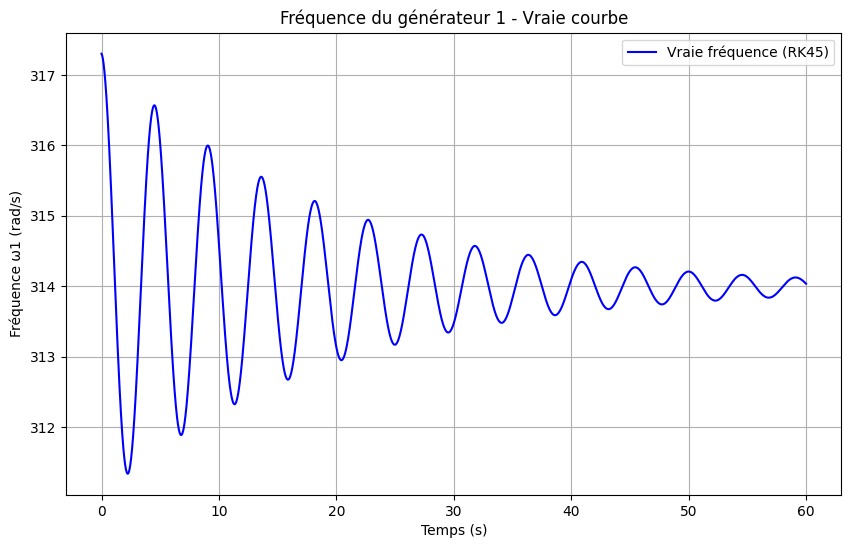

In [155]:
# Tracé de la courbe vraie uniquement
plt.figure(figsize=(10, 6))
plt.plot(t_true, omega1_true, label="Vraie fréquence (RK45)", color='blue')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence ω1 (rad/s)")
plt.title("Fréquence du générateur 1 - Vraie courbe")
plt.legend()
plt.grid()
plt.show()

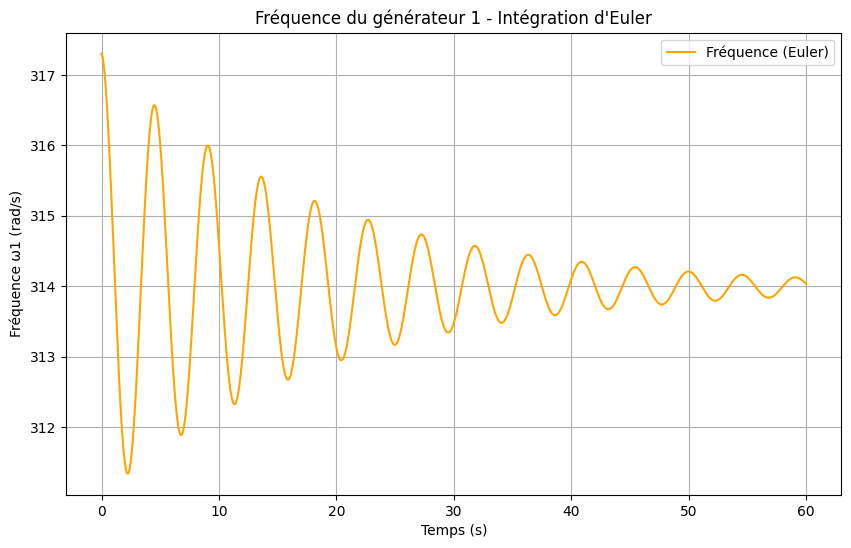

In [156]:
# Tracé de la courbe d'Euler uniquement
plt.figure(figsize=(10, 6))
plt.plot(t_euler, omega1_euler, label="Fréquence (Euler)", color='orange')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence ω1 (rad/s)")
plt.title("Fréquence du générateur 1 - Intégration d'Euler")
plt.legend()
plt.grid()
plt.show()

-> divergence du modèle Euler

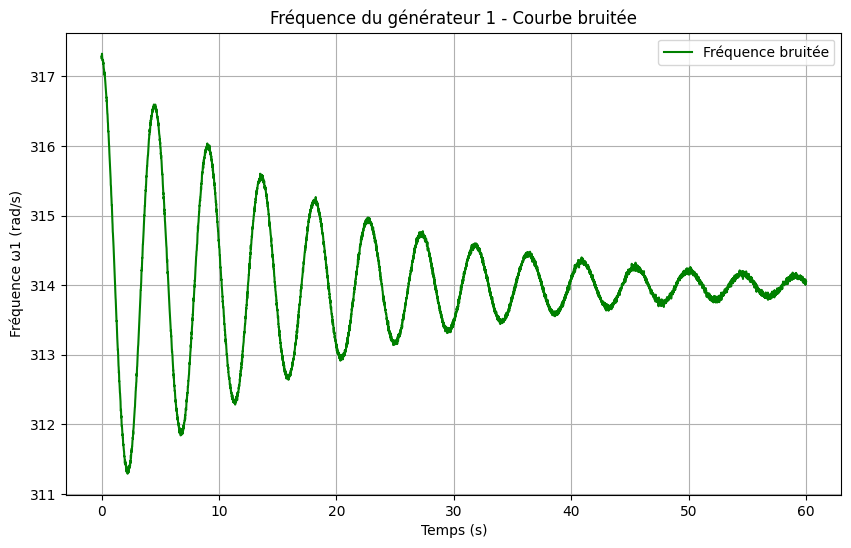

In [157]:
# Tracé de la courbe bruitée uniquement
plt.figure(figsize=(10, 6))
plt.plot(t_true, omega1_noisy, label="Fréquence bruitée", color='green')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence ω1 (rad/s)")
plt.title("Fréquence du générateur 1 - Courbe bruitée")
plt.legend()
plt.grid()
plt.show()

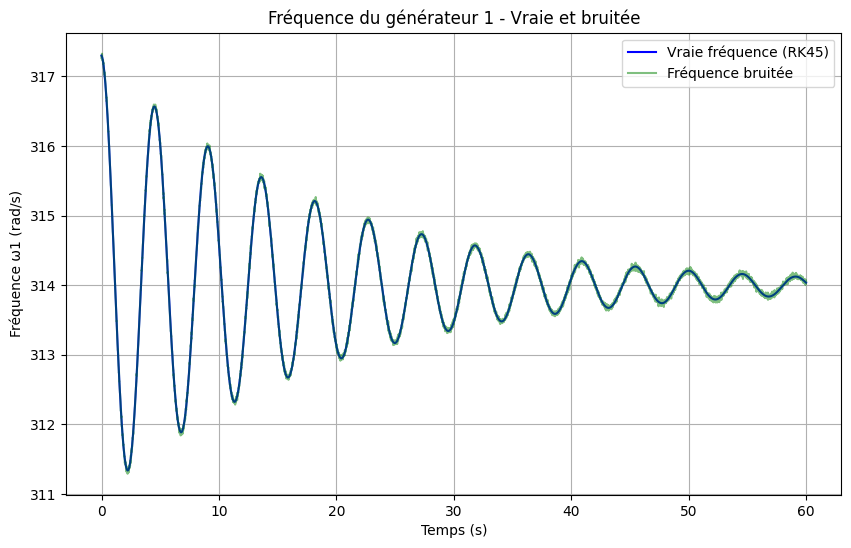

In [158]:
# Tracé des courbes vraie et bruitée
plt.figure(figsize=(10, 6))
plt.plot(t_true, omega1_true, label="Vraie fréquence (RK45)", color='blue')
plt.plot(t_true, omega1_noisy, label="Fréquence bruitée", color='green', alpha=0.5)
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence ω1 (rad/s)")
plt.title("Fréquence du générateur 1 - Vraie et bruitée")
plt.legend()
plt.grid()
plt.show()

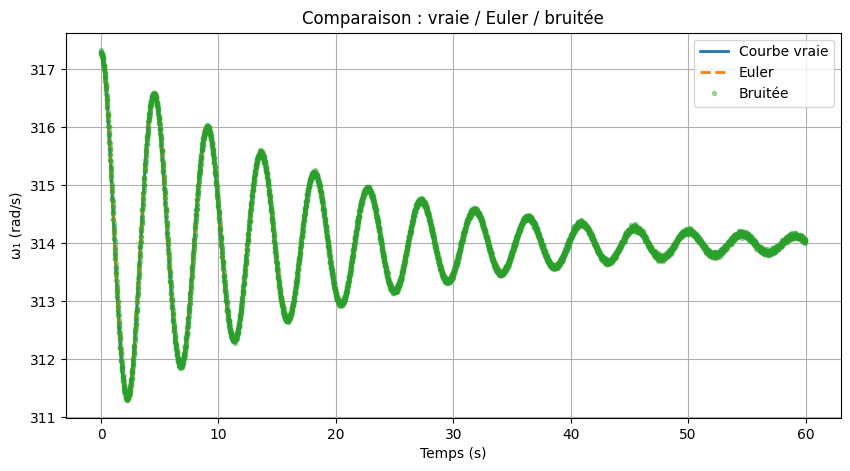

In [159]:
plt.figure(figsize=(10, 5))

plt.plot(t_true, omega1_true, label="Courbe vraie", linewidth=2)
plt.plot(t_euler, omega1_euler, "--", label="Euler", linewidth=2)
plt.plot(t_true, omega1_noisy, ".", label="Bruitée", alpha=0.4)

plt.xlabel("Temps (s)")
plt.ylabel("ω₁ (rad/s)")
plt.title("Comparaison : vraie / Euler / bruitée")
plt.legend()
plt.grid(True)

plt.show()

Modèle d'Euler simplifié  
$$X = [\theta_1, \omega_1, \theta_2, \omega_2]$$

In [160]:
# Fonction de dynamique simplifiée pour Euler
def dynamics_simple(X):
    theta1, omega1, theta2, omega2 = X

    F12 = KL * (theta1 - theta2)

    PG1 = PL1 + F12
    PG2 = PL2 - F12

    dtheta1 = omega1 - omega0
    domega1 = -(PG1 / omega0) / J1 - D1 * (omega1 - omega0) / J1

    dtheta2 = omega2 - omega0
    domega2 = -(PG2 / omega0) / J2 - D2 * (omega2 - omega0) / J2

    return np.array([dtheta1, domega1, dtheta2, domega2])


In [161]:
# Conditions initiales simplifiées
X0_simple = np.array([
    0.0,
    omega0 * 1.01,
    0.0,
    omega0 * 0.99
])

In [162]:
# Fonction d'intégration continue
def dynamics_continuous_simple(t, X):
    return dynamics_simple(X)

# Intégration courbe vraie avec dynamique simplifiée
t_span = (0.0, T_sim)
t_eval = np.arange(0.0, T_sim, dt_true)

sol_true_simple = solve_ivp(
    dynamics_continuous_simple,
    t_span,
    X0_simple,
    t_eval=t_eval,
    method="Radau"
)

X_true_simple = sol_true_simple.y.T   # shape (Nt, 7)
t_true_simple = sol_true_simple.t

In [163]:
# Boucle d'intégration d'Euler avec la dynamique simplifiée
X_euler_simple = np.zeros((len(t_euler), len(X0_simple)))
X_euler_simple[0] = X0_simple

for k in range(1, len(t_euler)):
    X_euler_simple[k] = X_euler_simple[k-1] + dt_euler * dynamics_simple(X_euler_simple[k-1])

In [164]:
# Extraction de la variable à tracer $\omega_1$ pour Euler simplifié
omega1_true_simple = X_true_simple[:, 1]
omega1_euler_simple = X_euler_simple[:, 1]

In [165]:
# Fonction d'intégration courbe bruitée avec dynamique simplifiée
sigma_omega_simple = 0.1  # écart-type du bruit (rad/s)

omega1_noisy_simple = omega1_true_simple + np.random.normal(
    0.0, sigma_omega_simple, size=len(omega1_true_simple)
)

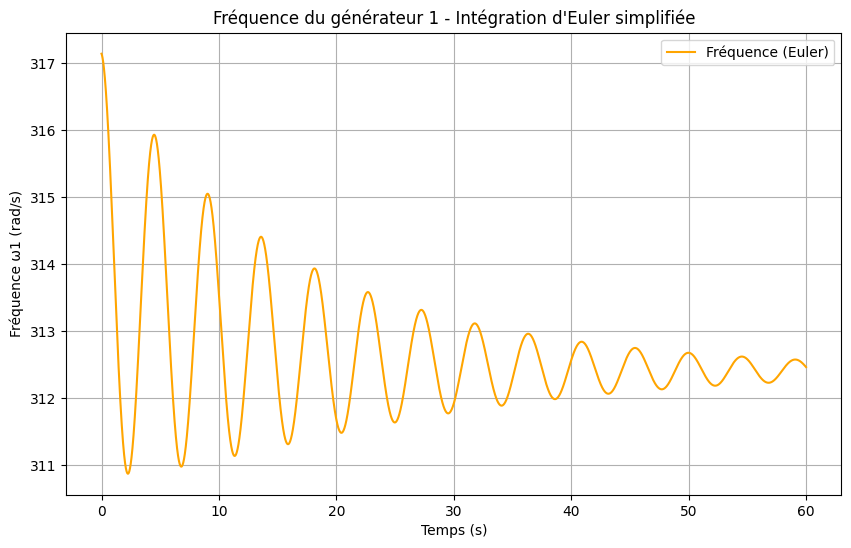

In [166]:
# Tracé de la courbe d'Euler simplifié
plt.figure(figsize=(10, 6))
plt.plot(t_euler, omega1_euler_simple, label="Fréquence (Euler)", color='orange')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence ω1 (rad/s)")
plt.title("Fréquence du générateur 1 - Intégration d'Euler simplifiée")
plt.legend()
plt.grid()
plt.show()

Tracé par rapport à $\omega_0$

In [167]:
delta_omega1_true = omega1_true - np.array(omega0)
delta_omega1_true_simple = omega1_true_simple - np.array(omega0)
delta_omega1_euler = omega1_euler - np.array(omega0)
delta_omega1_euler_simple = omega1_euler_simple - np.array(omega0)
delta_omega1_noisy = omega1_noisy - np.array(omega0)
delta_omega1_noisy_simple = omega1_noisy_simple - np.array(omega0)

In [168]:
print("dimension delta_omega1_true:", delta_omega1_true.shape)
print("dimension delta_omega1_euler_simple:", delta_omega1_euler_simple.shape)

dimension delta_omega1_true: (6000,)
dimension delta_omega1_euler_simple: (1200000,)


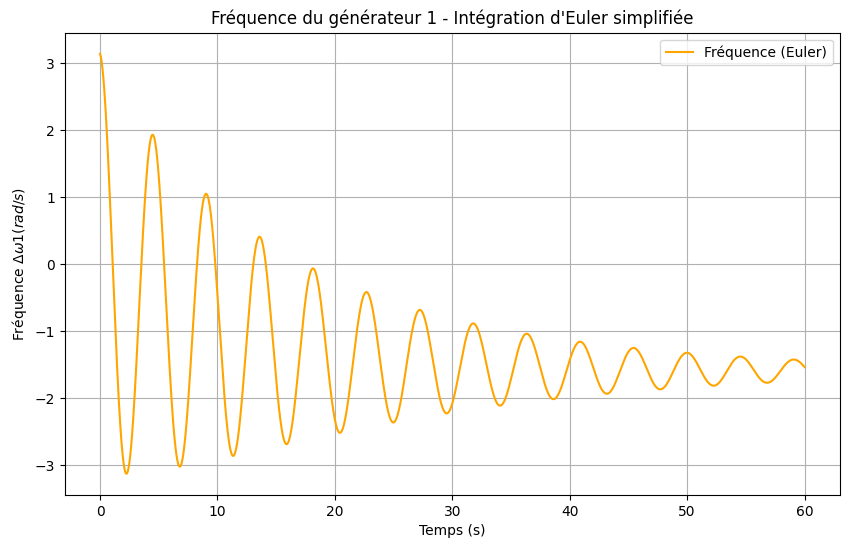

In [169]:
# Tracé de la courbe d'Euler simplifié par rapport à la fréquence nominale
plt.figure(figsize=(10, 6))
plt.plot(t_euler, delta_omega1_euler_simple, label="Fréquence (Euler)", color='orange')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence $\Delta\omega1 (rad/s)$")
plt.title("Fréquence du générateur 1 - Intégration d'Euler simplifiée")
plt.legend()
plt.grid()
plt.show()

In [170]:
print(f"Dimension Temps : {t_true_simple.shape}")
print(f"Dimension Données : {delta_omega1_true_simple.shape}")

Dimension Temps : (6000,)
Dimension Données : (6000,)


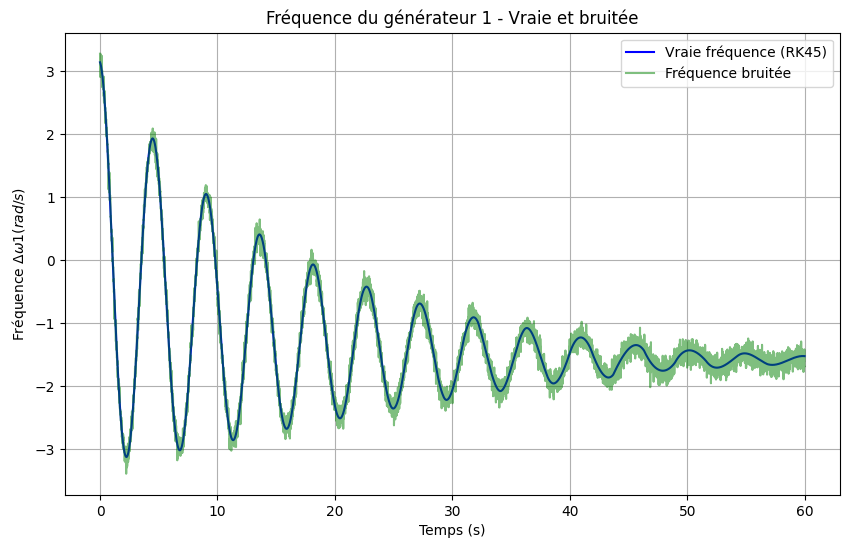

In [171]:
# Tracés des courbes vraie et bruitée par rapport à la fréquence nominale
plt.figure(figsize=(10, 6))
plt.plot(t_true_simple, delta_omega1_true_simple, label="Vraie fréquence (RK45)", color='blue')
plt.plot(t_true_simple, delta_omega1_noisy_simple, label="Fréquence bruitée", color='green', alpha=0.5)
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence $\Delta\omega1 (rad/s)$")
plt.title("Fréquence du générateur 1 - Vraie et bruitée")
plt.legend()
plt.grid()
plt.show()

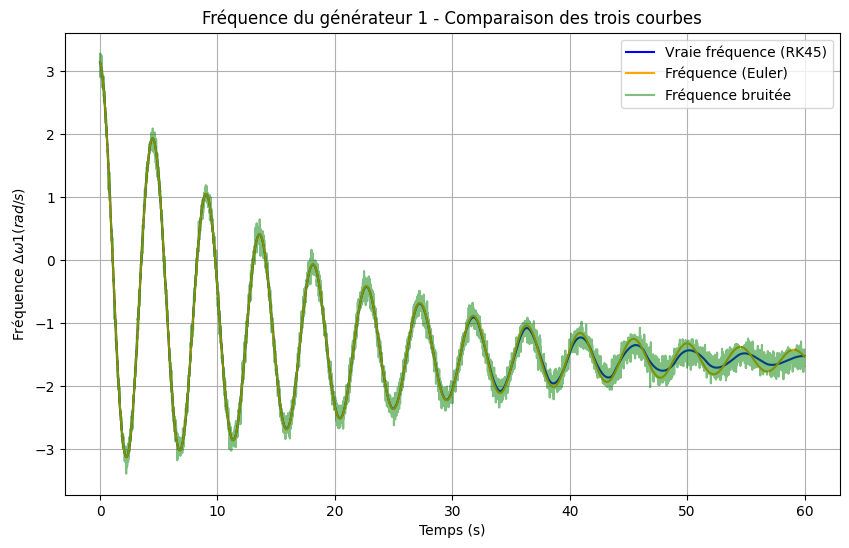

In [172]:
# Tracés des 3 courbes ensemble
plt.figure(figsize=(10, 6))
plt.plot(t_true, delta_omega1_true_simple, label="Vraie fréquence (RK45)", color='blue')
plt.plot(t_euler, delta_omega1_euler_simple, label="Fréquence (Euler)", color='orange')
plt.plot(t_true, delta_omega1_noisy_simple, label="Fréquence bruitée", color='green', alpha=0.5)
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence $\Delta\omega1 (rad/s)$")
plt.title("Fréquence du générateur 1 - Comparaison des trois courbes")
plt.legend()
plt.grid()
plt.show()

-> Euler est un modèle imparfait  
-> malgré la convergence, la valeur est fausse  
-> il faut utiliser un filtre de Kalman pour corriger cet écart

### 3. Filtre de Kalman

Paramètres physiques et numériques

In [173]:
import numpy as np
import matplotlib.pyplot as plt

In [174]:
# Paramètres physiques
omega0 = 314.0        # rad/s
KL = 3000.0           # rigidité de ligne
J = 10.0              # inertie
D = 1.0               # amortissement

# Temps
T = 10.0              # durée totale (s)
dt = 0.001           # pas de temps discret
N = int(T / dt)
t = np.linspace(0, T, N)

Modèle discret autour de l'équilibre

Vecteur d'état estimé
$$X_k = \begin{bmatrix} \Delta \theta_k \\ \Delta \omega_k \end{bmatrix}$$

Système d'équations différentielles (Linéarisé)
$$
\begin{cases} 
\dot{\Delta \theta} = \Delta \omega \\ 
\dot{\Delta \omega} = -\frac{KL}{J \omega_0} \Delta \theta - \frac{D}{J} \Delta \omega 
\end{cases}
$$

Représentation d'état continue
$$\dot{X} = A_c X$$

Avec la matrice d'état continue :
$$A_c = \begin{bmatrix} 0 & 1 \\ -\frac{KL}{J \omega_0} & -\frac{D}{J} \end{bmatrix}$$

In [175]:
Ac = np.array([
    [0.0, 1.0],
    [-KL / (J * omega0), -D / J]
])

Discrétisation (Schéma d'Euler) - Modèle d'évolution (Euler simplifié)
$$X_{k+1} = X_k + \Delta t A_c X_k + w_k$$
$$X_{k+1} = A_d X_k + w_k$$

Où la matrice d'état discrète est :
$$A_d = I + \Delta t A_c = \begin{bmatrix} 1 & \Delta t \\ -\frac{\Delta t KL}{J \omega_0} & 1 - \frac{\Delta t D}{J} \end{bmatrix}$$

In [176]:
Ad = np.eye(2) + dt * Ac

Modèle d'observation
$$y_k = C X_k + v_k$$
$$y_k = \Delta \omega_k + v_k$$

Avec :
* $C = \begin{bmatrix} 0 & 1 \end{bmatrix}$
* Bruit de processus : $w_k \sim \mathcal{N}(0, Q)$
* Bruit de mesure : $v_k \sim \mathcal{N}(0, R)$

In [177]:
C = np.array([[0.0, 1.0]])

Bruit du modèle (Euler imparfait)

In [178]:
Q = np.array([
    [1e-8, 0.0],
    [0.0, 1e-4]
])

Bruit de mesure

In [179]:
R = np.array([[1e-3]])

Simulation de la réalité

In [180]:
X_true = np.zeros((2, N)) 
X_true[:, 0] = [0.0, 0.0]
rng = np.random.default_rng(seed=0)

for k in range(N - 1):
    w = rng.multivariate_normal(mean=[0, 0], cov=Q)
    X_true[:, k+1] = Ad @ X_true[:, k] + w

Génération des mesures bruitées

In [181]:
# y = np.zeros(N)

# for k in range(N):
#     v = rng.normal(0, np.sqrt(R[0, 0]))
#     y[k] = C @ X_true[:, k] + v

print(delta_omega1_true.shape)
print(rng.normal(0, np.sqrt(R[0, 0]), size=N).shape)

(6000,)
(10000,)


In [182]:
rng = np.random.default_rng(0)
y = delta_omega1_true + rng.normal(0, np.sqrt(R[0, 0]), size=N)

ValueError: operands could not be broadcast together with shapes (6000,) (10000,) 

Filtre de Kalman discret

In [ ]:
# Initialisation du filtre de Kalman
X_hat = np.zeros((2, N))
P = np.eye(2)

In [ ]:
# Boucle du filtre de Kalman
for k in range(N - 1):

    # Prédiction
    X_pred = Ad @ X_hat[:, k]
    P_pred = Ad @ P @ Ad.T + Q

    # Gain de Kalman
    S = C @ P_pred @ C.T + R
    K = P_pred @ C.T @ np.linalg.inv(S)

    # Correction
    innovation = y[k+1] - C @ X_pred
    X_hat[:, k+1] = X_pred + (K @ innovation).flatten()
    P = (np.eye(2) - K @ C) @ P_pred


Comparaison des résultats

In [ ]:
print(delta_omega1_true.shape)
print(delta_omega1_euler_simple.shape)
print(t.shape)

(10000,)
(200000,)
(10000,)


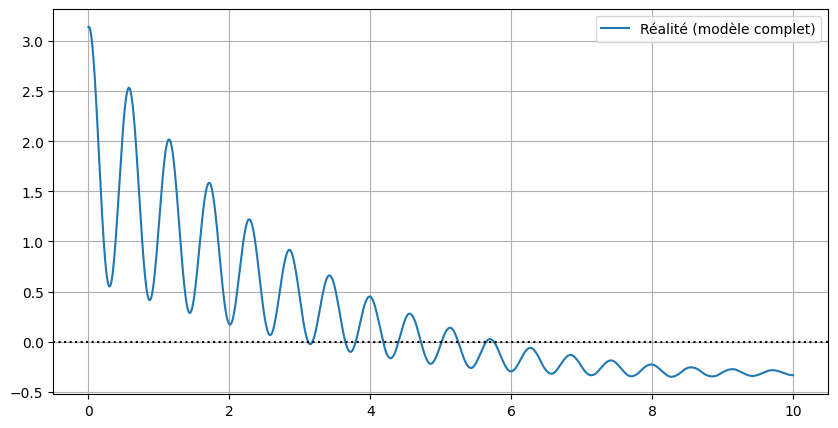

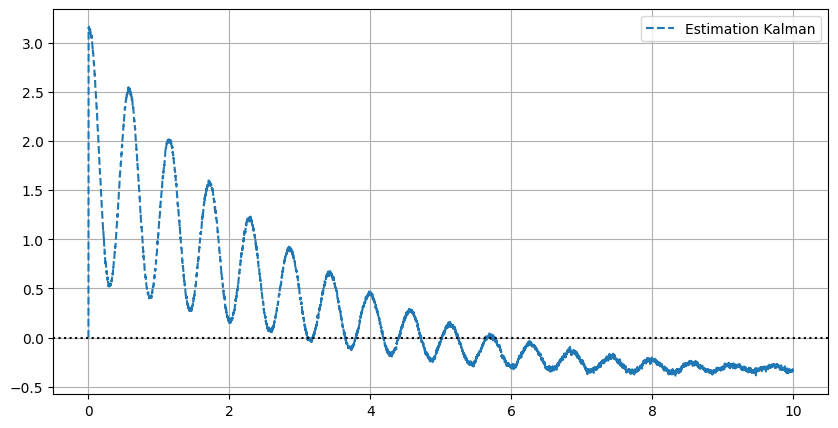

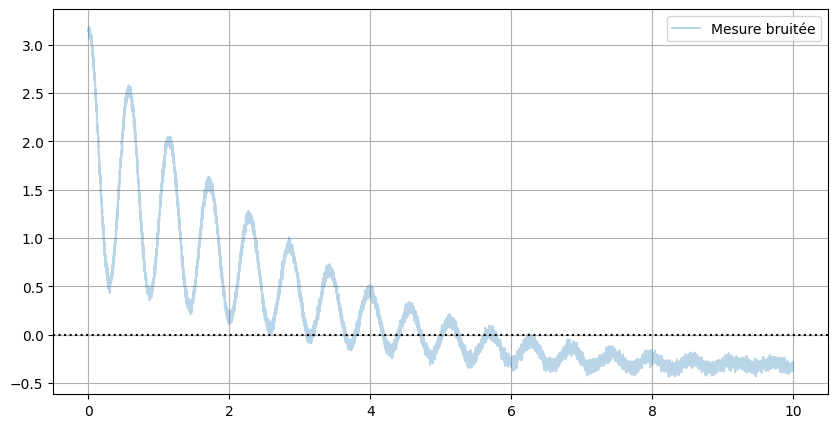

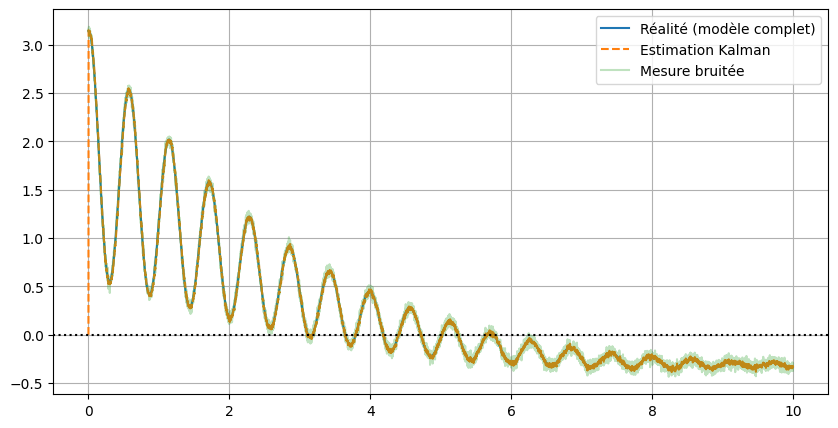

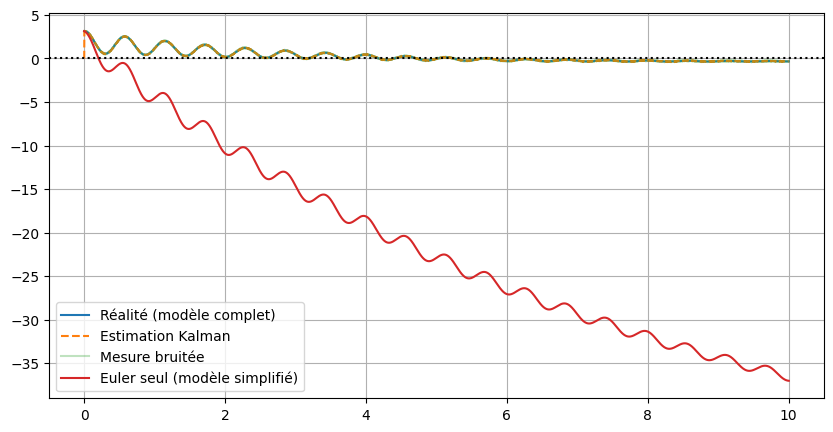

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(t, delta_omega1_true, label="Réalité (modèle complet)")
plt.axhline(0, color='k', linestyle=':')
plt.legend()
plt.grid()

plt.figure(figsize=(10,5))
plt.plot(t, X_hat[1, :], '--', label="Estimation Kalman")
plt.axhline(0, color='k', linestyle=':')
plt.legend()
plt.grid()

plt.figure(figsize=(10,5))
plt.plot(t, y, alpha=0.3, label="Mesure bruitée")
plt.axhline(0, color='k', linestyle=':')
plt.legend()
plt.grid()

plt.figure(figsize=(10,5))
plt.plot(t, delta_omega1_true, label="Réalité (modèle complet)")
plt.plot(t, X_hat[1, :], '--', label="Estimation Kalman")
plt.plot(t, y, alpha=0.3, label="Mesure bruitée")
plt.axhline(0, color='k', linestyle=':')
plt.legend()
plt.grid()

plt.figure(figsize=(10,5))
plt.plot(t, delta_omega1_true, label="Réalité (modèle complet)")
plt.plot(t, X_hat[1, :], '--', label="Estimation Kalman")
plt.plot(t, y, alpha=0.3, label="Mesure bruitée")
plt.plot(t_euler, delta_omega1_euler_simple, label="Euler seul (modèle simplifié)")
plt.axhline(0, color='k', linestyle=':')
plt.legend()
plt.grid()

plt.show()


### 4. Kalman sur modèle plus complexe

$$X = \begin{bmatrix} \Delta \theta_1 \\ \Delta \omega_1 \\ \Delta \theta_2 \\ \Delta \omega_2 \end{bmatrix}$$

$$
\begin{cases}
\dot{\theta}=\omega-\omega_0 \\
\dot{\omega}=f(\theta,\omega)
\end{cases}
$$

$$y=\begin{bmatrix} P_{G_1} \\ P_{G_2} \\ F_{12} \end{bmatrix}+v$$

$$
\begin{cases}
P_{G_1}=D(\omega_1-\omega_0)+K_L(\theta_1-theta_2) \\
P_{G_2}=D(\omega_2-\omega_0)-K_L(\theta_1-\theta_2) \\
F_{12}=K_L(\theta_1-\theta_2)
\end{cases}
$$

In [1]:
# # Fonction de mesure
# def h_measure(X):
#     theta1, omega1, theta2, omega2 = X

#     PG1 = D * (omega1 - omega0) + KL * (theta1 - theta2)
#     PG2 = D * (omega2 - omega0) - KL * (theta1 - theta2)
#     F12 = KL * (theta1 - theta2)

#     return np.array([PG1, PG2, F12])

In [2]:
# # Jacobienne de mesure H(X)
# def H_jacobian(X):
#     return np.array([
#         [ KL, D, -KL, 0 ],
#         [ -KL, 0, KL, D ],
#         [ KL, 0, -KL, 0 ]
#     ])

In [3]:
# sigma_PG1 = 0.02  # écart-type du bruit (rad/s)
# sigma_PG2 = 0.02  # écart-type du bruit (rad/s)
# sigma_F12 = 0.05  # écart-type du bruit (N)

# # Bruit de mesure R
# R = np.diag([
#     sigma_PG1**2,
#     sigma_PG2**2,
#     sigma_F12**2
# ])


Imports et paramètres globaux

In [4]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Paramètres physiques
omega0 = 314.0        # rad/s
KL = 3000.0           # rigidité de ligne
J1 = 10.0
J2 = 10.0
D1 = 1.0
D2 = 1.0

# Temps
dt = 1e-3
T = 20.0
N = int(T / dt)
t = np.linspace(0, T, N)


Modèle dynamique continu

In [6]:
def f_continuous(X):
    theta1, omega1, theta2, omega2 = X

    F12 = KL * (theta1 - theta2)

    dtheta1 = omega1 - omega0
    domega1 = -(D1 * (omega1 - omega0) + F12) / J1

    dtheta2 = omega2 - omega0
    domega2 = -(D2 * (omega2 - omega0) - F12) / J2

    return np.array([dtheta1, domega1, dtheta2, domega2])


In [7]:
def rk4_step(f, X, dt):
    k1 = f(X)
    k2 = f(X + 0.5 * dt * k1)
    k3 = f(X + 0.5 * dt * k2)
    k4 = f(X + dt * k3)
    return X + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


In [8]:
X_real = np.zeros((4, N))
X_real[:, 0] = np.array([0.0, omega0 + 2.0, 0.0, omega0 - 2.0])

for k in range(N - 1):
    X_real[:, k+1] = rk4_step(f_continuous, X_real[:, k], dt)


Mesure de puissances

In [9]:
def h_measure(X):
    theta1, omega1, theta2, omega2 = X

    delta_omega1 = omega1 - omega0
    delta_omega2 = omega2 - omega0
    delta_theta = theta1 - theta2

    PG1 = D1 * delta_omega1 + KL * delta_theta
    PG2 = D2 * delta_omega2 - KL * delta_theta
    F12 = KL * delta_theta


    return np.array([PG1/KL, PG2/KL, F12/KL])


In [19]:
sigma_PG = 5.0
sigma_F = 5.0

R = np.diag([
    1e-4,   # PG1
    1e-4,   # PG2
    1e-4    # F12
])



rng = np.random.default_rng(0)
Y = np.zeros((3, N))

for k in range(N):
    Y[:, k] = h_measure(X_real[:, k]) + rng.multivariate_normal(np.zeros(3), R)

# Normalisation des données de mesure
Y[0, :] /= KL
Y[1, :] /= KL
Y[2, :] /= KL



Modèle Euler

In [20]:
def f_discrete(X):
    return X + dt * f_continuous(X)


Jacobiennes

In [21]:
def F_jacobian(X):
    return np.array([
        [0,              1,            0,             0],
        [-KL/J1,     -D1/J1,        KL/J1,             0],
        [0,              0,            0,             1],
        [ KL/J2,          0,       -KL/J2,        -D2/J2]
    ]) * dt + np.eye(4)


In [22]:
def H_jacobian(X):
    return np.array([
        [ KL, D1, -KL,  0],
        [-KL,  0,  KL, D2],
        [ KL,  0, -KL,  0]
    ])


Filtre de Kalman étendu

In [23]:
X_hat = np.zeros((4, N))
P = np.eye(4)

X_hat[:, 0] = np.array([0.0, omega0, 0.0, omega0])

P = np.diag([10.0, 50.0, 10.0, 50.0])

Q = np.diag([
    1e-6,   # theta1
    1e-1,   # omega1
    1e-6,   # theta2
    1e-1    # omega2
])



In [24]:
for k in range(N - 1):

    # --- Prédiction ---
    X_pred = f_discrete(X_hat[:, k])
    F = F_jacobian(X_hat[:, k])
    P_pred = F @ P @ F.T + Q

    # --- Correction ---
    y_pred = h_measure(X_pred)
    H = H_jacobian(X_pred)

    innovation = Y[:, k+1] - y_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    X_hat[:, k+1] = X_pred + K @ innovation
    P = (np.eye(4) - K @ H) @ P_pred


Résultats

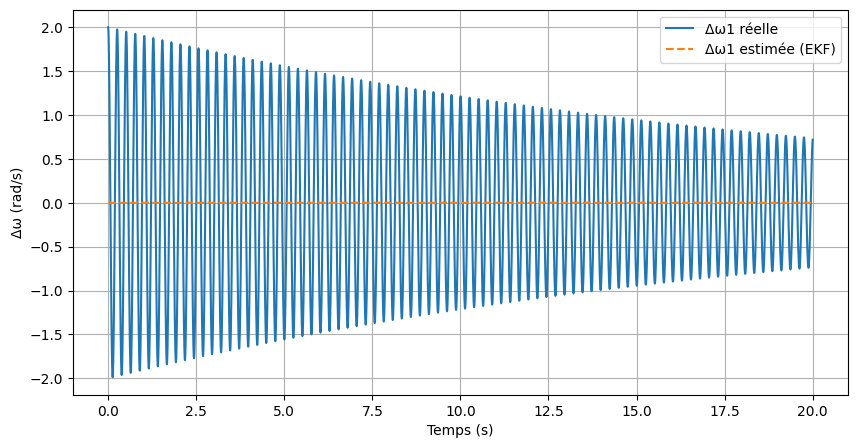

In [25]:
plt.figure(figsize=(10,5))
plt.plot(t, X_real[1, :] - omega0, label="Δω1 réelle")
plt.plot(t, X_hat[1, :] - omega0, '--', label="Δω1 estimée (EKF)")
plt.xlabel("Temps (s)")
plt.ylabel("Δω (rad/s)")
plt.legend()
plt.grid()
plt.show()


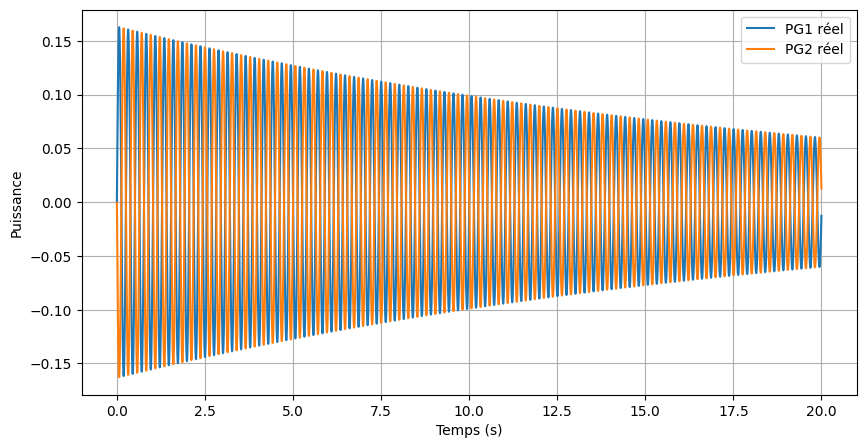

In [26]:
PG1_real = np.array([h_measure(X_real[:, k])[0] for k in range(N)])
PG2_real = np.array([h_measure(X_real[:, k])[1] for k in range(N)])

plt.figure(figsize=(10,5))
plt.plot(t, PG1_real, label="PG1 réel")
plt.plot(t, PG2_real, label="PG2 réel")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance")
plt.legend()
plt.grid()
plt.show()
